In [1]:
pip install gymnasium minigrid stable-baselines3 gym_minigrid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 49.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 5.4 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827728 sha256=dfbbaed7f9f21c8b6fd848bfdc2734c2a2c7afafb9e14ffc04f93d3b36a78889
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32622ca4658d53f31c79077
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is 

# MiniGrid Kitchen Environment — RL with PPO

This notebook walks through a complete reinforcement learning pipeline for a **custom MiniGrid kitchen environment**. The agent's task is to clean dirty dishes by:

1. **Picking up** dirty dishes (red balls) from the kitchen grid
2. **Rinsing** them at the sink (top-left corner) using the toggle action
3. **Loading** them into the dishwasher (bottom-right corner) using the toggle action

We use **Proximal Policy Optimization (PPO)** from Stable-Baselines3 with a custom CNN feature extractor to train the agent from pixel observations.

### Outline
1. Imports & Configuration
2. Custom Kitchen Environment Definition
3. Environment Registration
4. CNN Feature Extractor
5. Environment Factory
6. Training
7. Evaluation
8. Video Recording

## 1. Imports & Configuration

We import the following key libraries:

- **`gymnasium`** — the standard RL environment interface (successor to OpenAI Gym)
- **`minigrid`** — a suite of lightweight, grid-based environments perfect for RL research
- **`stable_baselines3`** — high-quality implementations of RL algorithms (PPO, A2C, DQN, etc.)
- **`torch`** — PyTorch, used under the hood by SB3 and for defining our custom CNN
- **`imageio`** — for saving rollout frames as video files

We also set a global seed and environment ID for reproducibility.

In [2]:
import gymnasium as gym
import minigrid
from minigrid.wrappers import ImgObsWrapper

import torch as th
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage

import imageio
from pathlib import Path
import numpy as np
import random
from typing import List, Tuple

CURRENT_DIR = Path(".")  # notebook runs from its own directory
ENV_ID = "MiniGrid-Kitchen-v0"
SEED = 42

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:307: DeprecationWarning: The package name gym_minigrid has been deprecated in favor of minigrid. Please uninstall gym_minigrid and install minigrid with `pip install minigrid`. Future releases will be maintained under the new package name minigrid.
  fn()
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### MiniGrid Internal Imports

We need access to MiniGrid's internal building blocks to create our custom environment:

| Class | Purpose |
|---|---|
| `MiniGridEnv` | Base class for all MiniGrid environments |
| `Grid` | The 2D grid that holds all objects |
| `Ball` | Used here to represent dirty dishes (red balls) |
| `Goal` | Used to represent the dishwasher location |
| `Wall` | Obstacles / countertops in the kitchen |

The import path varies between `minigrid` and `gym_minigrid` depending on the installed version, so we try both.

In [3]:
try:
    # Modern minigrid (gymnasium compatible) - for version 3.0+
    from minigrid.core.grid import Grid
    from minigrid.core.world_object import Ball, Goal, Wall
    from minigrid.minigrid_env import MiniGridEnv
except ImportError:
    # Fallback for older versions
    try:
        from minigrid.minigrid import MiniGridEnv, Grid, Ball, Goal, Wall
    except ImportError:
        from gym_minigrid.minigrid import MiniGridEnv, Grid, Ball, Goal, Wall

## 2. Custom Kitchen Environment

The `KitchenMiniGridEnv` extends MiniGrid's base environment with a custom kitchen scenario.

### Grid Layout
- **5×5 grid** surrounded by walls
- **Sink** at position `(1, 1)` — top-left interior
- **Dishwasher** (Goal tile) at position `(3, 3)` — bottom-right interior
- **1–3 dirty dishes** (red Balls) placed randomly
- **1 random wall** placed as a counter obstacle

### Reward Structure

| Event | Reward |
|---|---|
| Every step | **-0.01** (encourages efficiency) |
| Rinsing a dish at the sink | **+0.2** (intermediate reward for progress) |
| Loading a rinsed dish into dishwasher | **+1.0** (main objective reward) |
| Tight looping (optional) | **-0.5** (anti-loop penalty when enabled) |

### Dish Cleaning Logic
The agent must follow a specific sequence:
1. Navigate to a dish and **pick it up** (pickup action)
2. Navigate to the sink at `(1,1)` and **toggle** → marks the dish as "rinsed"
3. Navigate to the dishwasher at `(width-2, height-2)` and **toggle** → dish is cleaned, reward granted

### Anti-Loop Detection
When `anti_loop_penalty=True`, the environment tracks the agent's last 20 positions. If the last 6 positions only contain ≤ 2 unique locations, a penalty of -0.5 is applied to discourage the agent from getting stuck in repetitive movement patterns.

### Termination
The episode ends when:
- All dishes have been cleaned (no balls remain on the grid or in the agent's inventory), or
- The maximum number of steps (`max_steps=100`) is reached

In [4]:
import gymnasium as gym
import gymnasium.utils.seeding
from typing import Tuple

# Import MiniGrid components
try:
    # Modern minigrid (gymnasium compatible) - for version 3.0+
    from minigrid.core.grid import Grid
    from minigrid.core.world_object import Ball, Goal, Wall
    from minigrid.minigrid_env import MiniGridEnv
except ImportError:
    # Fallback for older versions
    try:
        from minigrid.minigrid import MiniGridEnv, Grid, Ball, Goal, Wall
    except ImportError:
        from gym_minigrid.minigrid import MiniGridEnv, Grid, Ball, Goal, Wall

class KitchenMiniGridEnv(MiniGridEnv):
    """
    MiniGrid environment representing a tiny kitchen:
    - Dirty dishes are represented as red Ball objects.
    - Dishwasher is a Goal tile: dropping a dish on the dishwasher counts as 'cleaned'.
    - NO SINK: Simplified task (Pickup -> Load).
    """

    def __init__(
        self,
        size: int = 8,
        num_dishes: Tuple[int, int] = (1, 3),
        max_steps: int = 200,
        seed: int = None,
        anti_loop_penalty: bool = False,
        render_mode: str = "rgb_array",
    ):
        self.kitchen_size = size
        self.num_dishes_range = num_dishes
        self.anti_loop_penalty = anti_loop_penalty

        # Define the mission space (required by newer minigrid versions)
        mission_space = gym.spaces.Text(max_length=256)

        super().__init__(
            mission_space=mission_space,
            width=size, height=size, max_steps=max_steps, see_through_walls=True,
            render_mode=render_mode
        )
        self.seed(seed)
        self.cleaned_count = 0
        self.total_dishes = 0
        self.dish_ids = []
        self._last_positions = []

    def seed(self, seed=None):
        """Explicitly define seed method for compatibility."""
        self.np_random, seed = gymnasium.utils.seeding.np_random(seed)
        return [seed]

    def _gen_grid(self, width, height):
        """Generate the kitchen grid layout."""
        # Create an empty grid with walls around the border
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # Place dishwasher (Goal) at bottom-right interior
        dx = width - 2
        dy = height - 2
        self.put_obj(Goal(), dx, dy)
        self.dishwasher_pos = (dx, dy)

        # --- SIMPLIFIED: NO SINK ---

        # Place 1-3 dirty dishes (red Ball objects) at random free cells
        num_dishes = self._rand_int(self.num_dishes_range[0], self.num_dishes_range[1] + 1)
        self.total_dishes = num_dishes # Track total for termination
        self.dish_ids = []
        placed = 0
        while placed < num_dishes:
            x = self._rand_int(1, width - 1)
            y = self._rand_int(1, height - 1)
            if self.grid.get(x, y) is None and (x, y) != self.dishwasher_pos:
                ball = Ball(color="red")
                ball.already_picked = False  # Track for one-time reward
                ball.dish_pos = (x, y)  # Store position for tracking
                self.put_obj(ball, x, y)
                self.dish_ids.append((x, y))  # Store as tuple for reliable tracking
                placed += 1

        # Place the agent at a random free cell
        self.place_agent()
        self.mission = "Clean the dishes: pick up and load into dishwasher."

    def step(self, action):
        """
        Extend step with custom reward shaping for the dish-cleaning task.
        IMPROVED: Better reward structure to encourage pickup and navigation.
        """
        pre_carrying = self.carrying
        pre_pos = tuple(self.agent_pos)
        # Track front position before action to identify which dish was picked up
        # Compute front position manually for compatibility
        try:
            if hasattr(self, 'front_pos'):
                pre_front_pos = tuple(self.front_pos)
            else:
                # Manual computation: front position based on agent direction
                ax, ay = self.agent_pos
                if self.agent_dir == 0:  # Right
                    pre_front_pos = (ax + 1, ay)
                elif self.agent_dir == 1:  # Down
                    pre_front_pos = (ax, ay + 1)
                elif self.agent_dir == 2:  # Left
                    pre_front_pos = (ax - 1, ay)
                else:  # Up
                    pre_front_pos = (ax, ay - 1)
        except:
            pre_front_pos = None

        obs, reward, terminated, truncated, info = super().step(action)

        # --- FIX: Prevent premature termination at dishwasher ---
        if terminated and self.agent_pos == self.dishwasher_pos:
             reward = 0
             terminated = False

        # Reduced step penalty - only apply when not making progress
        # This prevents the agent from learning that doing nothing is better
        reward = reward - 0.005  # Reduced from 0.01

        # --- PROXIMITY REWARD: Encourage getting close to dishes ---
        # Reward agent for being near dishes (helps with navigation)
        if self.carrying is None:  # Only when not carrying
            min_dist_to_dish = float('inf')
            # Check all positions in dish_ids to see if dishes still exist
            for dish_pos in self.dish_ids[:]:  # Use slice copy to avoid modification during iteration
                # Check if dish still exists on grid at this position
                try:
                    dish_obj = self.grid.get(dish_pos[0], dish_pos[1])
                    if dish_obj and dish_obj.type == "ball":
                        dist = abs(self.agent_pos[0] - dish_pos[0]) + abs(self.agent_pos[1] - dish_pos[1])
                        min_dist_to_dish = min(min_dist_to_dish, dist)
                except (IndexError, TypeError):
                    # Position might be invalid, skip it
                    continue
            
            if min_dist_to_dish < float('inf'):
                # Reward for being close (closer = higher reward)
                if min_dist_to_dish == 0:
                    reward += 0.1  # Standing on/near dish
                elif min_dist_to_dish == 1:
                    reward += 0.05  # Adjacent to dish
                elif min_dist_to_dish == 2:
                    reward += 0.02  # Two steps away

        # --- ENCOURAGE PICKUP ACTION ---
        # Give small reward for attempting pickup action (even if it fails)
        # This helps the agent explore the pickup action
        if action == self.actions.pickup:
            # Check if there's a dish in front of the agent
            try:
                fwd_pos = self.front_pos
                fwd_cell = self.grid.get(*fwd_pos)
                if fwd_cell and fwd_cell.type == "ball":
                    reward += 0.1  # Reward for attempting pickup near dish
                else:
                    reward += 0.01  # Small reward for trying pickup action (encourages exploration)
            except:
                # Fallback: still reward pickup attempts to encourage exploration
                reward += 0.01

        # --- IMPROVED Pickup Reward (much larger) ---
        if pre_carrying is None and self.carrying is not None:
             if not getattr(self.carrying, 'already_picked', False):
                  reward += 2.0  # Increased from 0.5 - makes pickup very attractive
                  self.carrying.already_picked = True
                  # Remove picked dish from dish_ids tracking
                  dish_pos_to_remove = None
                  
                  # Method 1: Use stored dish_pos attribute (most reliable)
                  if hasattr(self.carrying, 'dish_pos'):
                      dish_pos_to_remove = self.carrying.dish_pos
                  # Method 2: Use front position where pickup happened
                  elif pre_front_pos and pre_front_pos in self.dish_ids:
                      dish_pos_to_remove = pre_front_pos
                  # Method 3: Find closest dish to agent (fallback)
                  else:
                      if self.dish_ids:
                          min_dist = float('inf')
                          for pos in self.dish_ids:
                              dist = abs(self.agent_pos[0] - pos[0]) + abs(self.agent_pos[1] - pos[1])
                              if dist < min_dist:
                                  min_dist = dist
                                  dish_pos_to_remove = pos
                  
                  if dish_pos_to_remove and dish_pos_to_remove in self.dish_ids:
                      self.dish_ids.remove(dish_pos_to_remove)

        carried = self.carrying

        # --- REWARD FOR CARRYING DISH TOWARD DISHWASHER ---
        # Encourage agent to move toward dishwasher when carrying
        if carried is not None and carried.type == "ball":
            dist_to_dishwasher = abs(self.agent_pos[0] - self.dishwasher_pos[0]) + abs(self.agent_pos[1] - self.dishwasher_pos[1])
            # Small reward for being close to dishwasher with dish
            if dist_to_dishwasher <= 1:
                reward += 0.1

        # Toggle action handles loading
        if action == self.actions.toggle:
            # Loading: carrying ANY ball at the dishwasher
            if self.agent_pos == self.dishwasher_pos and carried is not None and carried.type == "ball":
                reward += 5.0  # Increased from 2.5 - big reward for completing the job
                self.cleaned_count += 1
                self.carrying = None

        # --- IMPROVED TERMINATION ---
        # Terminate immediately if we have cleaned as many dishes as we started with.
        if self.cleaned_count >= self.total_dishes:
            terminated = True
            reward += 2.0  # Increased from 1.0 - bonus for finishing

        # --- DEBUG INFO ---
        if terminated or truncated:
            info["dishes_cleaned"] = self.cleaned_count

        return obs, reward, terminated, truncated, info

## 3. Environment Registration

We register the custom environment with Gymnasium's registry so it can be instantiated via `gym.make("MiniGrid-Kitchen-v0", ...)`. This is the standard pattern for creating reusable custom environments.

The `try/except` block handles the case where the environment is already registered (e.g., if this cell is re-run).

In [5]:
from gymnasium.envs.registration import register, registry

# Force re-registration to ensure max_episode_steps is updated
if ENV_ID in registry:
    del registry[ENV_ID]

register(
    id=ENV_ID,
    entry_point=lambda **kwargs: KitchenMiniGridEnv(**kwargs),
    max_episode_steps=200, # Increased to 200
)

## 4. CNN Feature Extractor

Since our observations are **pixel images** of the grid (thanks to `ImgObsWrapper`), we need a convolutional neural network to extract meaningful features before feeding them into the PPO policy and value networks.

### Architecture

```
Input Image (C, H, W)
    │
    ├── Conv2d(C → 32, 3×3, padding=1) + ReLU
    ├── Conv2d(32 → 64, 3×3, padding=1) + ReLU
    ├── Conv2d(64 → 64, 3×3, padding=1) + ReLU
    ├── Flatten
    └── Linear(flattened → 128) + ReLU
         │
         └── 128-dim feature vector
```

Key design choices:
- **3×3 kernels with padding=1** preserve spatial dimensions, which is important for small grid images
- **No pooling layers** — the MiniGrid observations are already very small (e.g., 7×7×3), so we don't want to downsample further
- The flattened CNN output is projected to a **128-dimensional** feature vector that PPO's policy and value heads consume

In [6]:
class MinigridFeaturesExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        n_input_channels = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        # Dynamically compute the flattened size by passing a dummy input
        with th.no_grad():
            sample = observation_space.sample()[None]
            sample = th.as_tensor(sample).float()
            n_flatten = self.cnn(sample).shape[1]
        self.linear = nn.Sequential(nn.Linear(n_flatten, features_dim), nn.ReLU())

    def forward(self, observations):
        return self.linear(self.cnn(observations))


policy_kwargs = dict(
    features_extractor_class=MinigridFeaturesExtractor,
    features_extractor_kwargs=dict(features_dim=128),
)

## 5. Environment Factory

The `make_env` function is a **factory** that returns a callable which creates a properly wrapped environment. This pattern is required by SB3's vectorized environment wrappers.

The wrapping chain is:
1. `gym.make(...)` → creates the raw `KitchenMiniGridEnv`
2. `ImgObsWrapper(env)` → extracts only the image observation (discarding the mission string and direction), returning `(H, W, C)` arrays
3. `DummyVecEnv([make_env()])` → wraps it in SB3's vectorized env interface (batch dimension)
4. `VecTransposeImage(vec_env)` → transposes images from `(H, W, C)` to `(C, H, W)` as PyTorch expects

In [7]:
from stable_baselines3.common.monitor import Monitor

def make_env(seed=SEED, size=8, anti_loop_penalty=False):
    """Returns a callable that creates a wrapped MiniGrid kitchen environment."""
    def _init():
        env = gym.make(
            ENV_ID,
            size=size,
            num_dishes=(1, 3),
            max_steps=200,
            seed=seed,
            anti_loop_penalty=anti_loop_penalty,
            render_mode="rgb_array"
        )
        # Wrap with Monitor to track episode stats (reward, length)
        env = Monitor(env)
        env = ImgObsWrapper(env)
        return env

    return _init

## 6. Training

We train a **PPO (Proximal Policy Optimization)** agent — one of the most popular and reliable on-policy RL algorithms.

### PPO Hyperparameters

| Parameter | Value | Description |
|---|---|---|
| `learning_rate` | 3e-4 | Adam optimizer learning rate |
| `n_steps` | 1024 | Number of steps per rollout before each update |
| `batch_size` | 64 | Minibatch size for each gradient step |
| `n_epochs` | 10 | Number of passes over the rollout buffer per update |
| `gamma` | 0.99 | Discount factor — how much the agent values future rewards |
| `gae_lambda` | 0.95 | GAE (Generalized Advantage Estimation) smoothing factor |
| `clip_range` | 0.2 | PPO clipping range — limits how much the policy can change per update |
| `ent_coef` | 0.02 | Entropy bonus — encourages exploration |
| `vf_coef` | 0.5 | Value function loss coefficient |
| `max_grad_norm` | 0.5 | Gradient clipping to prevent exploding gradients |

### Training Pipeline
1. Set random seeds for reproducibility
2. Create a vectorized environment with image transposition
3. Instantiate PPO with the custom CNN feature extractor
4. Train for 200,000 timesteps (adjustable)
5. Save the trained model to disk

In [8]:
from stable_baselines3.common.callbacks import BaseCallback

class DebugCallback(BaseCallback):
    """
    Custom callback for plotting additional values in tensorboard.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.dishes_cleaned = []
        self.episode_rewards = []

    def _on_step(self) -> bool:
        # Check for episode end in the vectorized environment
        for info in self.locals['infos']:
            if "dishes_cleaned" in info:
                self.dishes_cleaned.append(info["dishes_cleaned"])
                self.logger.record("custom/dishes_cleaned", info["dishes_cleaned"])
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])

        return True

    def _on_rollout_end(self) -> None:
        # Print stats at the end of each rollout (every n_steps)
        if self.dishes_cleaned:
            avg_cleaned = np.mean(self.dishes_cleaned)
            avg_rew = np.mean(self.episode_rewards) if self.episode_rewards else 0.0
            print(f"[Debug] Rollout End - Avg Dishes Cleaned: {avg_cleaned:.2f} | Avg Reward: {avg_rew:.2f}")
            # Log to Tensorboard
            self.logger.record("rollout/avg_dishes_cleaned", avg_cleaned)

        self.dishes_cleaned = []
        self.episode_rewards = []

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
th.manual_seed(SEED)

# Create vectorized environment
# TRAIN ON 8x8 GRID with ANTI-LOOP PENALTY
vec_env = DummyVecEnv([make_env(seed=SEED, size=8, anti_loop_penalty=True)])
vec_env = VecTransposeImage(vec_env)

# Initialize PPO with custom CNN policy
# IMPROVED: Increased entropy for better exploration of pickup action
model = PPO(
    "CnnPolicy",
    vec_env,
    policy_kwargs=policy_kwargs,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.1,  # Increased from 0.05 to 0.1 for better exploration
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    verbose=1,
    tensorboard_log=str(CURRENT_DIR / "logs"),
)

# Train the agent
print("Starting training on 8x8 grid (Improved Rewards: Proximity + Pickup incentives) for 300k steps...")
# Increased timesteps for better learning
model.learn(total_timesteps=300_000, progress_bar=True, callback=DebugCallback())

# Save the trained model
model_path = CURRENT_DIR / "model"
model.save(model_path)
print(f"Model saved to {model_path}.zip")

Using cuda device
Starting training on 8x8 grid (Improved Rewards: Proximity + Pickup incentives) for 300k steps...
Logging to logs/PPO_1


Output()

/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs 
returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")

[Debug] Rollout End - Avg Dishes Cleaned: 0.00 | Avg Reward: 1.94

...

[Debug] Rollout End - Avg Dishes Cleaned: 3.00 | Avg Reward: 2.12

-----------------------------------------
| custom/                 |             |
|    dishes_cleaned       | 3           |
| rollout/                |             |
|    avg_dishes_cleaned   | 3           |
|    ep_len_mean          | 1           |
|    ep_rew_mean          | 2.13        |
| time/                   |             |
|    fps                  | 284         |
|    iterations           | 292         |
|    time_elapsed         | 1052        |
|    total_timesteps      | 299008      |
| train/                  |             |
|    approx_kl            | 0.047340557 |
|    clip_fraction        | 0.283       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.981      |
|    explained_variance   | 0.998       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.194      |
|    n_updates            | 2910        |
|    policy_gradient_loss | -0.0591     |
|    value_loss           | 0.0003      |
----------------------------------

[Debug] Rollout End - Avg Dishes Cleaned: 3.00 | Avg Reward: 2.10

-----------------------------------------
| custom/                 |             |
|    dishes_cleaned       | 3           |
| rollout/                |             |
|    avg_dishes_cleaned   | 3           |
|    ep_len_mean          | 1           |
|    ep_rew_mean          | 2.05        |
| time/                   |             |
|    fps                  | 284         |
|    iterations           | 293         |
|    time_elapsed         | 1055        |
|    total_timesteps      | 300032      |
| train/                  |             |
|    approx_kl            | 0.049654953 |
|    clip_fraction        | 0.317       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.03       |
|    explained_variance   | 0.998       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.187      |
|    n_updates            | 2920        |
|    policy_gradient_loss | -0.0605     |
|    value_loss           | 0.000255    |
----------------------------------

Model saved to model.zip


## 7. Evaluation

After training, we evaluate the agent's performance over multiple episodes using SB3's `evaluate_policy` utility. This runs the trained policy in the environment for `n_eval_episodes` episodes and computes the **mean** and **standard deviation** of the total episode rewards.

A higher mean reward indicates that the agent has learned to:
- Efficiently pick up dishes
- Rinse them at the sink
- Load them into the dishwasher
- Minimize wasted steps

We use a different seed (`SEED + 1`) for evaluation to test generalization to unseen random configurations.

In [9]:
# Use DummyVecEnv and VecTransposeImage to match training preprocessing
eval_env = DummyVecEnv([make_env(seed=SEED + 1, size=8, anti_loop_penalty=True)])
eval_env = VecTransposeImage(eval_env)

mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=20)
print(f"\nEvaluation results (20 episodes): Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")

eval_env.close()


Evaluation results (20 episodes): Mean reward: 4.50 ± 3.83


## 8. Video Recording

Finally, we record a video of the trained agent performing a single episode. This is useful for:
- **Visual debugging** — seeing if the agent actually follows the rinse → load sequence
- **Presentations** — demonstrating the learned behavior
- **Sanity checks** — verifying the environment renders correctly

The video is saved as `demo.mp4` at 6 FPS. Each frame is captured using `env.render(mode="rgb_array")`.

In [10]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np

# Create a vectorized environment exactly like training
# We use the SAME SEED (42) to verify it works on the configuration it learned
video_env = DummyVecEnv([make_env(seed=SEED, size=8, anti_loop_penalty=True)])
video_env = VecTransposeImage(video_env)

frames: List[np.ndarray] = []
obs = video_env.reset()

# Access the underlying raw environment for rendering and info
raw_env = video_env.envs[0]

def annotate_frame(env, frame, step_idx, action_name=None, reward=0.0):
    """Overlay text on the frame to explain what's happening."""
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)

    # Status info
    carried = getattr(env.unwrapped, "carrying", None)
    status = "Idling"
    if carried:
        status = f"Carrying {carried.color} dish"
        if getattr(carried, "rinsed", False):
            status += " (Rinsed)"

    cleaned = getattr(env.unwrapped, "cleaned_count", 0)

    text = f"Step: {step_idx}\nStatus: {status}\nCleaned: {cleaned}"
    if action_name:
        text += f"\nAction: {action_name}"

    draw.text((5, 5), text, fill=(255, 255, 255))
    return np.array(img)

# Initial frame
frame = raw_env.render()
frames.append(annotate_frame(raw_env, frame, 0))

done = False
steps = 0
max_steps = 200
total_reward = 0

while not done and steps < max_steps:
    # Use deterministic=False to help agent break out of loops (matches training behavior)
    action, _ = model.predict(obs, deterministic=False)

    obs, reward, dones, infos = video_env.step(action)
    total_reward += reward[0]

    # Check if episode ended
    done = dones[0]

    # Get action name for annotation
    action_name = raw_env.unwrapped.actions(action[0]).name

    frame = raw_env.render()
    annotated_frame = annotate_frame(raw_env, frame, steps + 1, action_name, reward[0])
    frames.append(annotated_frame)

    steps += 1
    if done:
        print(f"Episode finished in {steps} steps. Total Reward: {total_reward:.2f}")
        break

output_path = CURRENT_DIR / "demo.mp4"
imageio.mimsave(output_path, frames, fps=6)
print(f"Video saved to {output_path} ({len(frames)} frames, {steps} steps)")

video_env.close()

Episode finished in 200 steps. Total Reward: 3.00
Video saved to demo.mp4 (201 frames, 200 steps)


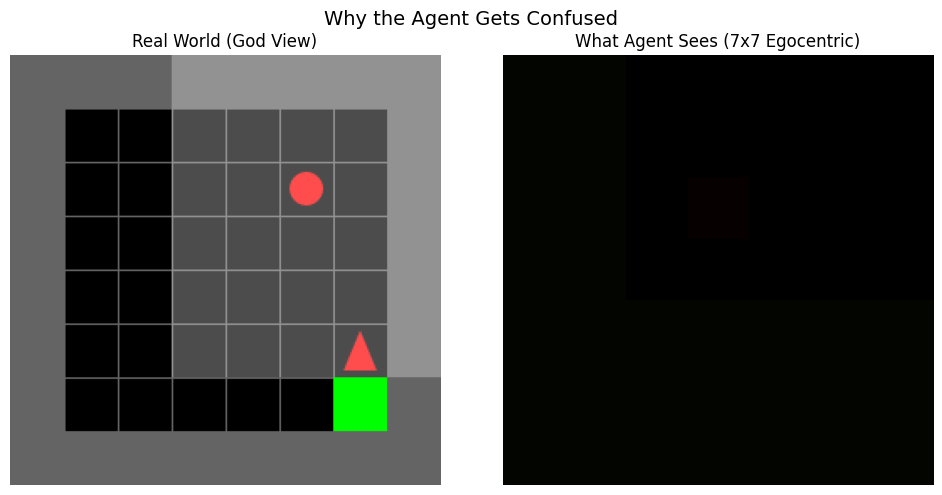

In [11]:
import matplotlib.pyplot as plt

# Get the last observation from the video environment
# obs is currently in (C, H, W) format from the wrapper
obs_agent = obs[0]  # Shape (3, 7, 7)

# Transpose back to (H, W, C) for visualization
obs_agent_viz = np.transpose(obs_agent, (1, 2, 0))

# Create a side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 1. Real World (Global View)
axes[0].imshow(raw_env.render())
axes[0].set_title("Real World (God View)")
axes[0].axis("off")

# 2. Agent's Brain (Egocentric View)
axes[1].imshow(obs_agent_viz)
axes[1].set_title("What Agent Sees (7x7 Egocentric)")
axes[1].axis("off")

plt.suptitle("Why the Agent Gets Confused", fontsize=14)
plt.tight_layout()
plt.show()

---

### Next Steps

- **Enable anti-loop penalty**: Set `anti_loop_penalty=True` in `make_env()` to discourage repetitive agent behavior
- **Increase training timesteps**: Try 500k or 1M steps for better convergence
- **Tune hyperparameters**: Experiment with `ent_coef`, `learning_rate`, or `n_steps`
- **Scale the kitchen**: Increase `size` and `num_dishes` for a harder task
- **Monitor with TensorBoard**: Run `tensorboard --logdir logs/` to visualize training curves